# Núcleo 3 — Simulador de sensibilidad de la coparticipación

Dado un shock porcentual en la recaudación tributaria nacional coparticipable,
calculo acá el impacto resultante en pesos para cada provincia (con foco en Córdoba),
usando `scripts/simulator.py` y los coeficientes de Ley 23.548 relevados en el
Núcleo 2.

El simulador parte de tres supuestos (el detalle completo está en el docstring de
`scripts/simulator.py` y en `docs/methodology.md`): `recaudacion_base` es la masa
coparticipable TOTAL (incluye lo que retiene la Nación y el Fondo ATN, no solo lo que
reciben las provincias); uso únicamente los coeficientes de Ley 23.548, sin la
compensación del Consenso Fiscal (Ley 27.429), porque es un monto históricamente fijo
en pesos, no una proporción de la recaudación corriente; y los adelantos de
coparticipación (por ejemplo, el Decreto 219/2026) son una partida aparte —anticipos a
cuenta— que no cambian el coeficiente de reparto de nadie, así que no los modelo
acá.

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

BASE_DIR = Path("..").resolve() if Path("../data").exists() else Path(".").resolve()
sys.path.insert(0, str(BASE_DIR / "scripts"))

from simulator import simular_shock
from coeficientes_ley23548 import COEFICIENTES_COPARTICIPACION

COLOR_NEGATIVO = "#e34948"
COLOR_POSITIVO = "#2a78d6"
COLOR_CORDOBA_BORDE = "#0b0b0b"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID_COLOR = "#e1e0d9"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.edgecolor": GRID_COLOR,
    "axes.labelcolor": INK_SECONDARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "text.color": INK_PRIMARY,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
})

FIGURES_DIR = BASE_DIR / "output" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

suma_coeficientes_provincias = sum(COEFICIENTES_COPARTICIPACION.values())
print(f"Suma de los 24 coeficientes (participación de las provincias en la masa coparticipable total): {suma_coeficientes_provincias:.4f}")

Suma de los 24 coeficientes (participación de las provincias en la masa coparticipable total): 0.5876


## 1. Contraste contra una cifra pública: caída de recaudación de comienzos de 2026

IARAF estimó que en el primer cuatrimestre de 2026 la recaudación tributaria nacional
cayó en términos reales unos $5,1 billones, de los cuales $1,4 billones representaron
menos coparticipación para las provincias.

No conseguí, por las mismas restricciones de acceso a internet de este entorno, una
cifra oficial de "masa coparticipable de referencia" para ese período específico. Así
que armo una `recaudacion_base` propia a partir de datos que sí tengo (la
coparticipación nominal 2025 del Núcleo 1), y la uso junto con esa cifra pública para
chequear consistencia interna — no como una predicción a ciegas.

In [2]:
df_n1 = pd.read_csv(BASE_DIR / "data" / "processed" / "coparticipacion_real.csv")
total_2025 = df_n1[df_n1["anio"] == 2025]["monto_nominal"].sum() * 1e6  # el CSV está en millones de pesos

# Aproximación: un cuatrimestre = 4/12 del año. Es una aproximación declarada, no un dato real mensual.
recibido_provincias_4m = total_2025 * 4 / 12

# "Gross-up": lo que reciben las provincias es el `suma_coeficientes_provincias` de la masa total.
recaudacion_base_4m = recibido_provincias_4m / suma_coeficientes_provincias

print(f"Coparticipación nominal recibida por las 24 jurisdicciones en 2025: ${total_2025:,.0f}")
print(f"Aproximación a 4 meses: ${recibido_provincias_4m:,.0f}")
print(f"Masa coparticipable total estimada (4 meses): ${recaudacion_base_4m:,.0f}")

Coparticipación nominal recibida por las 24 jurisdicciones en 2025: $48,951,168,366,528
Aproximación a 4 meses: $16,317,056,122,176
Masa coparticipable total estimada (4 meses): $27,768,985,912,485


In [3]:
# Variación % que, aplicada a esta base, reproduce el impacto de $1,4 billones que reportó IARAF.
IMPACTO_OBJETIVO_IARAF = -1.4e12

variacion_implicita = IMPACTO_OBJETIVO_IARAF / suma_coeficientes_provincias / recaudacion_base_4m
print(f"Variación % de recaudación implícita: {variacion_implicita:.2%}")

resultado_validacion = simular_shock(variacion_implicita, recaudacion_base_4m, COEFICIENTES_COPARTICIPACION)
print(f"Impacto total en provincias (modelo): ${resultado_validacion['total_impacto_provincias']:,.0f}")
print(f"Impacto reportado por IARAF:          ${IMPACTO_OBJETIVO_IARAF:,.0f}")

# Chequeo de consistencia independiente: ¿qué fracción de la caída TOTAL de recaudación
# (no solo la coparticipable) representa la masa coparticipable afectada?
CAIDA_TOTAL_RECAUDACION_IARAF = -5.1e12
monto_coparticipable_afectado = resultado_validacion["monto_total_afectado"]
tasa_coparticipabilidad_implicita = monto_coparticipable_afectado / CAIDA_TOTAL_RECAUDACION_IARAF
print(f"\nTasa de 'coparticipabilidad' implícita (masa coparticipable / caída total): {tasa_coparticipabilidad_implicita:.1%}")

Variación % de recaudación implícita: -8.58%
Impacto total en provincias (modelo): $-1,400,000,000,000
Impacto reportado por IARAF:          $-1,400,000,000,000

Tasa de 'coparticipabilidad' implícita (masa coparticipable / caída total): 46.7%


Por construcción, el modelo reproduce exactamente el impacto de $1,4 billones de
esa cifra pública (así derivé la variación % implícita) — eso no es una predicción
ciega, es una calibración. Lo que sí es una validación genuina es que los dos números
que salen de esa calibración son plausibles:

- Una caída real de recaudación coparticipable de ~8,6% en el período es un orden de
  magnitud razonable para un shock macro relevante, ni extremo ni trivial.
- La "tasa de coparticipabilidad" implícita (~46,7% de la caída total de recaudación
  afecta a la masa coparticipable) cae dentro del rango que suele citarse para
  Argentina (aproximadamente 40-50% de la recaudación nacional total es coparticipable
  bajo la Ley 23.548, el resto son impuestos no coparticipables como derechos de
  exportación, o regímenes con otro destino).

Si estos dos números hubieran salido, por ejemplo, con una tasa de coparticipabilidad
del 90% o del 5%, sería una señal de que algo en la `recaudacion_base` estimada (o en
la cifra de IARAF) no encaja — no fue el caso acá. Esta es la validación: consistencia
entre una fuente externa y los datos propios del proyecto (Núcleo 1), no una
comparación contra una tercera fuente independiente de recaudación coparticipable real
de 2026, que no conseguí dadas las restricciones de acceso a internet de este
entorno.

## 2. Impacto por provincia

¿Cómo se hubiera repartido ese impacto de $1,4 billones entre las 24 jurisdicciones?
¿Dónde queda Córdoba? Muestro dos vistas: en pesos absolutos (donde Buenos Aires
domina solo por tener el coeficiente más grande, igual que en el Núcleo 1) y en % de
lo que cada provincia recibe hoy de coparticipación — la pregunta más relevante para
cada una: "¿qué tan grande es este golpe para mí?".

Impacto estimado para Córdoba: $-120,073,396,869 (unos $120.1 mil millones menos, -8.7% de lo que recibe)


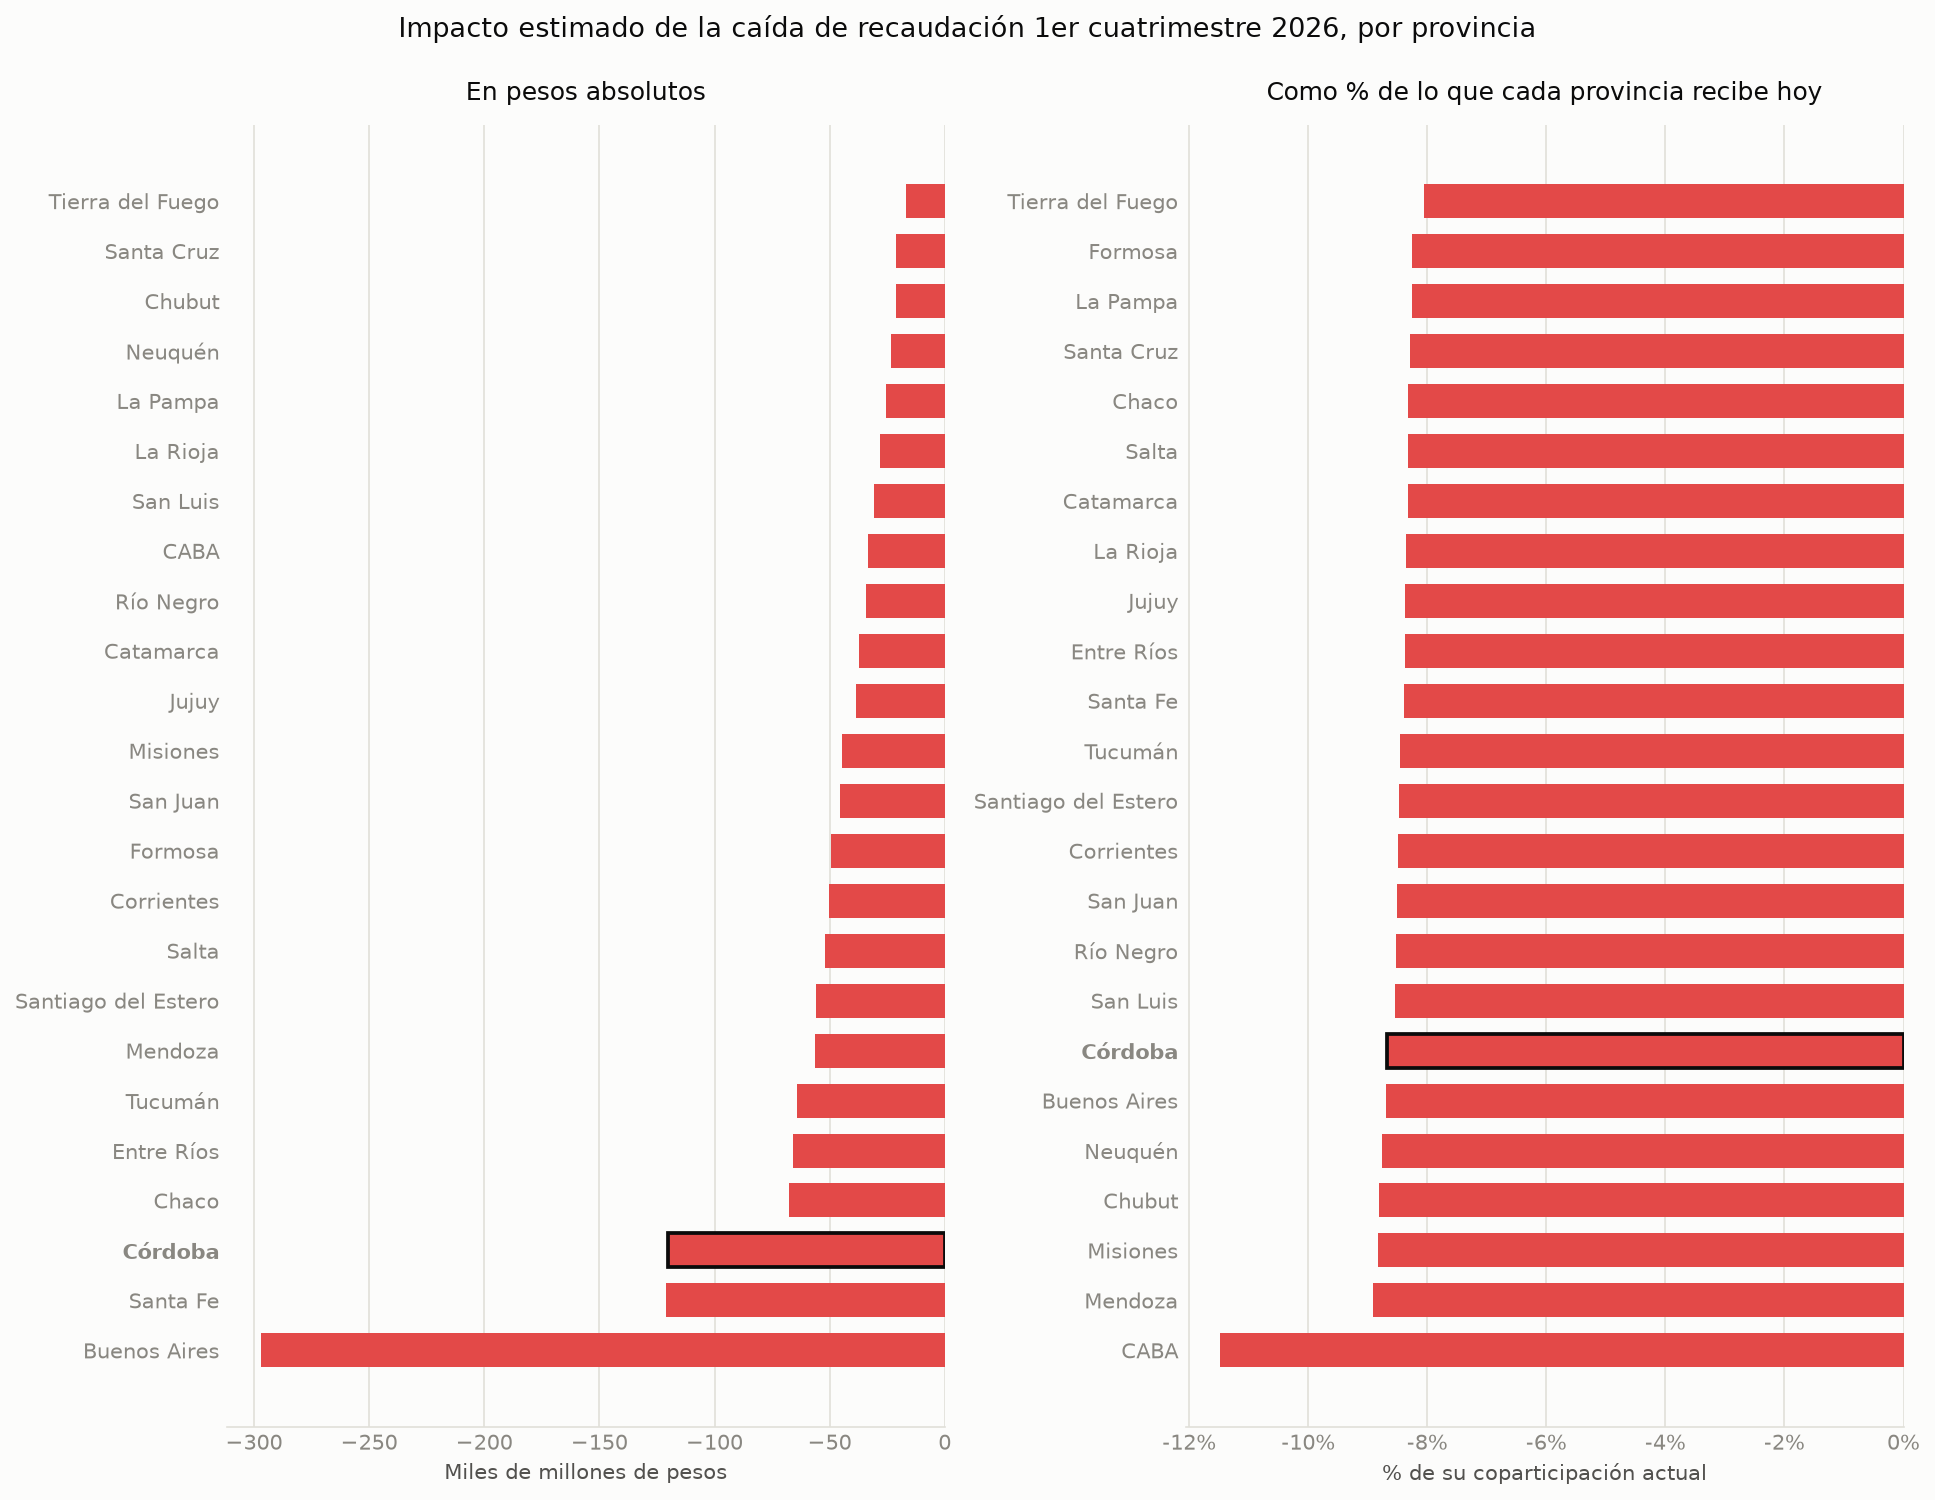

In [4]:
# Coparticipación actual de cada provincia, en la misma base de 4 meses que
# recaudacion_base_4m, para poder calcular el impacto como % de lo que recibe hoy
# (parámetro opcional de simular_shock, sin usar hasta ahora en este notebook).
coparticipacion_actual_4m = {
    provincia: monto * 1e6 * 4 / 12
    for provincia, monto in df_n1[df_n1["anio"] == 2025].set_index("provincia")["monto_nominal"].items()
}

resultado_validacion = simular_shock(
    variacion_implicita, recaudacion_base_4m, COEFICIENTES_COPARTICIPACION,
    coparticipacion_actual_por_provincia=coparticipacion_actual_4m,
)

impacto_df = pd.DataFrame(resultado_validacion["por_provincia"]).sort_values("impacto_pesos")

cordoba_impacto = impacto_df[impacto_df["provincia"] == "Córdoba"]["impacto_pesos"].iloc[0]
cordoba_impacto_pct = impacto_df[impacto_df["provincia"] == "Córdoba"]["impacto_pct_de_su_coparticipacion"].iloc[0]
print(f"Impacto estimado para Córdoba: ${cordoba_impacto:,.0f} (unos ${abs(cordoba_impacto)/1e9:,.1f} mil millones menos, {cordoba_impacto_pct:.1%} de lo que recibe)")

fig, axes = plt.subplots(1, 2, figsize=(13, 10), dpi=150)

bordes = [COLOR_CORDOBA_BORDE if p == "Córdoba" else "none" for p in impacto_df["provincia"]]
grosor = [1.8 if p == "Córdoba" else 0 for p in impacto_df["provincia"]]

axes[0].barh(impacto_df["provincia"], impacto_df["impacto_pesos"] / 1e9, color=COLOR_NEGATIVO, edgecolor=bordes, linewidth=grosor, height=0.68)
axes[0].set_title("En pesos absolutos", fontsize=12, color=INK_PRIMARY, pad=12)
axes[0].set_xlabel("Miles de millones de pesos", fontsize=10)

impacto_pct_df = impacto_df.sort_values("impacto_pct_de_su_coparticipacion")
bordes_pct = [COLOR_CORDOBA_BORDE if p == "Córdoba" else "none" for p in impacto_pct_df["provincia"]]
grosor_pct = [1.8 if p == "Córdoba" else 0 for p in impacto_pct_df["provincia"]]
axes[1].barh(impacto_pct_df["provincia"], impacto_pct_df["impacto_pct_de_su_coparticipacion"] * 100, color=COLOR_NEGATIVO, edgecolor=bordes_pct, linewidth=grosor_pct, height=0.68)
axes[1].set_title("Como % de lo que cada provincia recibe hoy", fontsize=12, color=INK_PRIMARY, pad=12)
axes[1].set_xlabel("% de su coparticipación actual", fontsize=10)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

for ax in axes:
    ax.grid(axis="x", color=GRID_COLOR, linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(GRID_COLOR)
    ax.tick_params(axis="both", length=0)
    for label in ax.get_yticklabels():
        if label.get_text() == "Córdoba":
            label.set_fontweight("bold")

fig.suptitle("Impacto estimado de la caída de recaudación 1er cuatrimestre 2026, por provincia", fontsize=13, color=INK_PRIMARY, y=0.995)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "simulador_validacion_1cuatrimestre2026.png", dpi=300, facecolor=SURFACE)
plt.show()

En pesos absolutos, Buenos Aires parece la más golpeada simplemente por ser la más
grande. En términos relativos —% de lo que cada provincia recibe hoy— 23 de las 24
jurisdicciones caen en una banda angosta, entre -8,0% y -8,9% (Córdoba: -8,7%), muy
cerca de la variación % del shock (-8,6%) — consistente con que el simulador reparte
el shock proporcional al coeficiente de cada una.

La excepción es CABA, con -11,5%, claramente por fuera de esa banda. Esto no es un
supuesto del simulador sino un eco de una limitación ya documentada en el Núcleo 2: el
coeficiente de CABA usado acá (1,4%) lo corregí a mano porque el documento fuente
traía el valor de 2018 (3,75%); esa corrección hace que el coeficiente ya no guarde
con la coparticipación que CABA efectivamente recibió en 2025 la misma relación
proporcional que sí mantienen las demás provincias (cuyos coeficientes no toqué). En
términos prácticos: bajo este supuesto de reparto proporcional, ninguna provincia está
estructuralmente más o menos expuesta que otra a un shock de recaudación general — la
exposición relativa depende de qué tan dependiente sea cada una de la coparticipación
en su propio presupuesto (esto lo exploro para Córdoba en el Núcleo 4), no del tamaño
de su coeficiente.

## 3. Ejemplos de uso: escenarios de caída real de 5%, 10% y 15%

Usando la misma `recaudacion_base` (masa coparticipable estimada para un cuatrimestre),
¿cómo cambiaría el impacto sobre Córdoba ante distintas magnitudes de shock?

In [5]:
escenarios = [-0.05, -0.10, -0.15]
filas = []
for variacion in escenarios:
    resultado = simular_shock(variacion, recaudacion_base_4m, COEFICIENTES_COPARTICIPACION)
    cordoba = [p for p in resultado["por_provincia"] if p["provincia"] == "Córdoba"][0]
    filas.append({
        "escenario": f"{variacion:.0%}",
        "impacto_total_provincias": resultado["total_impacto_provincias"],
        "impacto_cordoba": cordoba["impacto_pesos"],
    })

tabla_escenarios = pd.DataFrame(filas)
tabla_escenarios["impacto_total_provincias"] = tabla_escenarios["impacto_total_provincias"].map(lambda x: f"${x/1e9:,.1f} mil M")
tabla_escenarios["impacto_cordoba"] = tabla_escenarios["impacto_cordoba"].map(lambda x: f"${x/1e9:,.1f} mil M")
tabla_escenarios

,escenario,impacto_total_provincias,impacto_cordoba
0,-5%,$-815.9 mil M,$-70.0 mil M
1,-10%,"$-1,631.7 mil M",$-139.9 mil M
2,-15%,"$-2,447.6 mil M",$-209.9 mil M


## 4. Simulador interactivo

Deslizá para elegir una caída (o suba) real de recaudación y ver el impacto resultante
en Córdoba y en el total de provincias, en vivo.

In [6]:
import ipywidgets as widgets
from IPython.display import display

slider = widgets.FloatSlider(
    value=-8.6, min=-30, max=30, step=0.5,
    description="Variación %:", continuous_update=False,
    style={"description_width": "initial"}, layout=widgets.Layout(width="500px"),
)
salida = widgets.Output()


def actualizar(change):
    with salida:
        salida.clear_output(wait=True)
        variacion = slider.value / 100
        resultado = simular_shock(variacion, recaudacion_base_4m, COEFICIENTES_COPARTICIPACION)
        cordoba = [p for p in resultado["por_provincia"] if p["provincia"] == "Córdoba"][0]

        print(f"Variación de recaudación coparticipable: {variacion:+.1%}")
        print(f"Impacto total en las 24 provincias: ${resultado['total_impacto_provincias']/1e9:,.1f} mil millones")
        print(f"Impacto en Córdoba: ${cordoba['impacto_pesos']/1e9:,.1f} mil millones")

        fig, ax = plt.subplots(figsize=(6, 3.2), dpi=120)
        color = COLOR_NEGATIVO if cordoba["impacto_pesos"] < 0 else COLOR_POSITIVO
        ax.barh(["Córdoba"], [cordoba["impacto_pesos"] / 1e9], color=color, height=0.5)
        ax.axvline(0, color=GRID_COLOR, linewidth=1)
        ax.set_xlabel("Miles de millones de pesos")
        for spine in ["top", "right", "left"]:
            ax.spines[spine].set_visible(False)
        ax.tick_params(axis="both", length=0)
        fig.tight_layout()
        plt.show()


slider.observe(actualizar, names="value")
display(slider, salida)
actualizar(None)

FloatSlider(value=-8.6, continuous_update=False, description='Variación %:', layout=Layout(width='500px'), max…

Output()

## 5. Conclusiones

- El simulador (`scripts/simulator.py`) es una función pura, documentada y con 9 tests
  automáticos (`scripts/test_simulator.py`), que reparte un shock de recaudación entre
  provincias según los coeficientes de la Ley 23.548.
- El contraste contra la caída de recaudación de comienzos de 2026 (reportada por
  IARAF) arrojó una tasa de coparticipabilidad implícita (~46,7%) y una variación real
  implícita (~-8,6%) consistentes con lo esperable — no es una predicción verificada
  contra una fuente independiente, sino un chequeo de consistencia entre esa cifra
  pública y los datos propios del Núcleo 1.
- Para un shock de recaudación real de esa magnitud, Córdoba pierde del orden de $120
  mil millones de pesos de coparticipación.